## Assignment




## Ann_CNN assignment

## by yogesh singh batch 13

### a)	What are vanishing and exploding gradients? How do they affect neural networks? Explain in detail.


b)	Use the Bank customer churn dataset from below Kaggle link and create an end-to-end project on Jupyter/Colab to predict the Churn.

https://www.kaggle.com/datasets/santoshd3/bank-customers/data


i.	Download the dataset from above link and load it into your Python environment.
ii.	Perform the EDA and do the visualizations.

iii.	Check the distributions/skewness in the variables and do the transformations if required.

iv.	Check/Treat the outliers and do the feature scaling if required.

v.	Build Deep Learning model using ANN with multiple hidden layers.

vi.	Apply the dropout regularization and early stopping techniques to improve model performance.

vii.	Use the modelCheckpoint also to store the parameters after each epoch.

viii.	Use the KerasTuner to tune to best parameters (No. of hidden layers, optimizers, loss function, activation functions etc.)

ix.	Compare the accuracies of different models and finalize the best model.



## ans.b

The vanishing gradient problem occurs when gradients become extremely small (close to zero) during backpropagation.

As the error signal moves backward through many hidden layers, the gradients keep shrinking.

Eventually, they become so small that the earlier layers receive almost no updates.

As a result, these layers stop learning.


It mainly occurs because:

Deep neural networks have many layers.

Activation functions like Sigmoid and Tanh have derivatives less than 1.

During backpropagation, these small derivatives are multiplied repeatedly.

For example,

0.5 × 0.5 × 0.5 × 0.5 × 0.5
= 0.03125

With many layers,

0.5 × 0.5 × ... × 0.5
≈ 0

Thus, the gradient almost disappears.

## Effects of Vanishing Gradient in nural network

Early layers learn very slowly.

Training becomes extremely slow.

Model accuracy remains poor.

The network may never converge.

Deep networks become difficult to train.


## The exploding gradient

The exploding gradientproblem occurs when gradients become extremely large during backpropagation.

Instead of shrinking, they grow exponentially.

Large gradients produce huge weight updates.

This makes training unstable.


It happens when:

Large weights exist.

Improper weight initialization.

Deep neural networks.

Repeated multiplication of values greater than 1.

Example,

2 × 2 × 2 × 2 × 2
= 32

With many layers,

2 × 2 × 2 × ... × 2
= Very Large Number

The gradient becomes enormous.

## Effects of Exploding Gradient in neural networks
Very large weight updates.

Training becomes unstable.

Loss suddenly increases.

Model fails to converge.

Training may produce NaN values.

Accuracy fluctuates significantly
.
Real-Life Example

Suppose someone is adjusting the volume of a speaker.

Instead of increasing the volume by 1 unit, they increase it by 100 units.

The sound becomes extremely loud and uncontrollable.

Similarly, exploding gradients make weight updates excessively large.


## churn prediction using ann

## Importing the libraries

numpy for numerical operations ana array hndling and pandas for data mnipulations and analysis

In [1]:
import numpy as np
import pandas as pd
import os


df = pd.read_csv('Churn _Modeling.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## checking missing value

In [2]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

## checking the duplicates

to check the duplicate rows present in dataset

In [3]:
df.duplicated().sum()

np.int64(0)

## cheking data types

to check th e data type in each column

In [4]:
df.dtypes

RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

## checking dataset shape

use to display the column name dtypes,non null value and memory usage

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


## checking dataset shape ,rows and column

In [6]:
df.shape

(10000, 14)

In [7]:
# Verdict of the 9 Charts:
# 1. Target Variable (Exited): Shows a significant class imbalance; roughly 80% stayed and 20% churned.
# 2. Histograms: Reveals Age is slightly right-skewed, while CreditScore and EstimatedSalary are relatively uniform/normal.
# 3. Boxplots: Detects outliers in 'Age' (older customers) and 'CreditScore' (very low scores).
# 4. Correlation Heatmap: Shows low linear correlation between numerical features, suggesting non-linear relationships drive churn.
# 5. Pairplot: Confirms no obvious linear clusters between numerical variables across the dataset.
# 6. Categorical Countplots: Shows 'France' is the most common geography and 'Male' is slightly more represented than 'Female'.
# 7. Age vs Exited: Suggests that older customers (40-60 range) are more likely to exit compared to younger ones.
# 8. Balance vs Exited: Reveals many customers with 0 balance, but churn occurs across all balance levels.
# 9. Salary Distribution: Confirms that salary is uniformly distributed, meaning wealth (salary-wise) isn't a direct indicator of churn.

In [8]:
pwd

'C:\\Users\\user\\final eda3\\final python eda\\vs code deployment\\bank_customers_ann_assignment'

## visuvilaization part,,

usin matplotlib , seaborn to understand pattern visuvilised ,distributions , relation ship and outliers present,in dataset

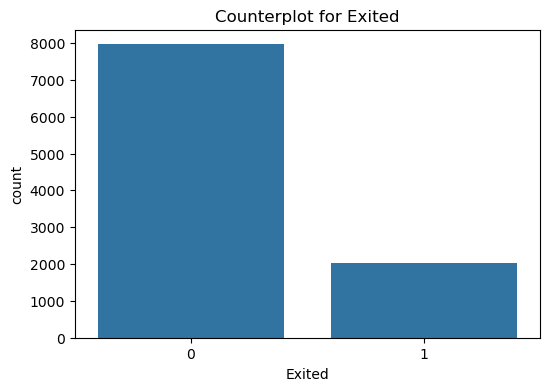

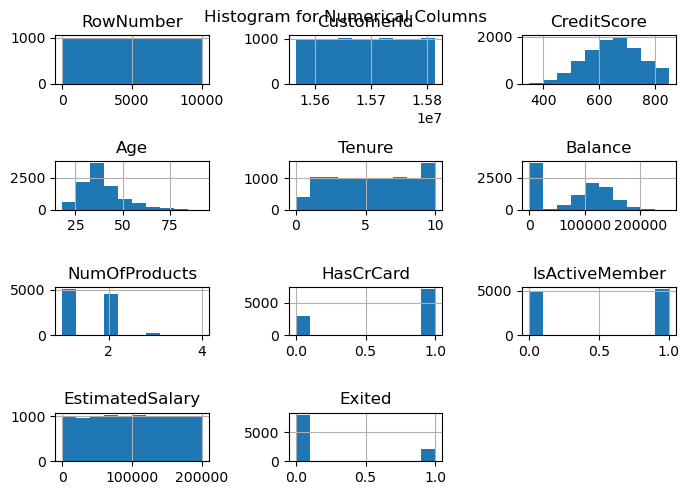

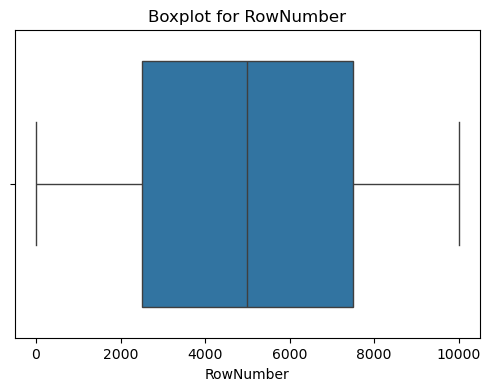

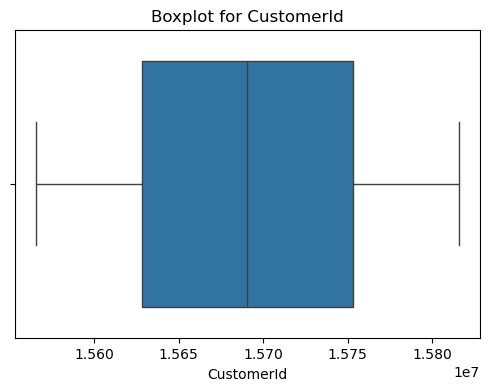

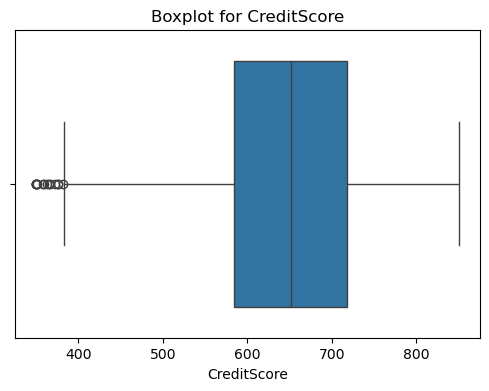

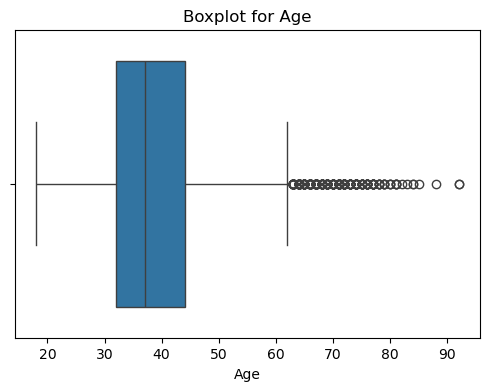

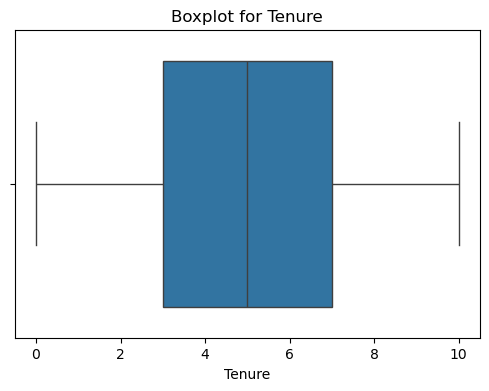

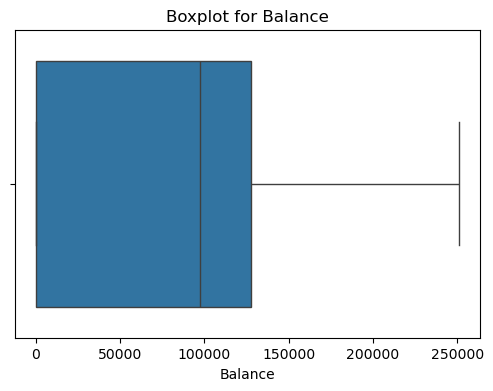

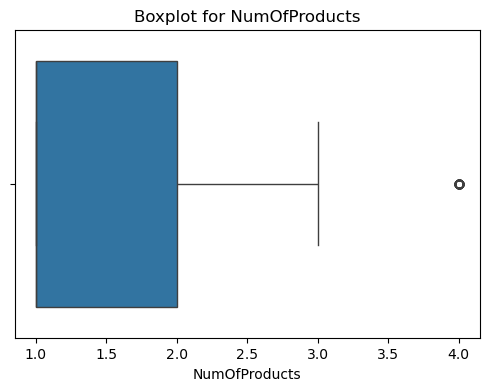

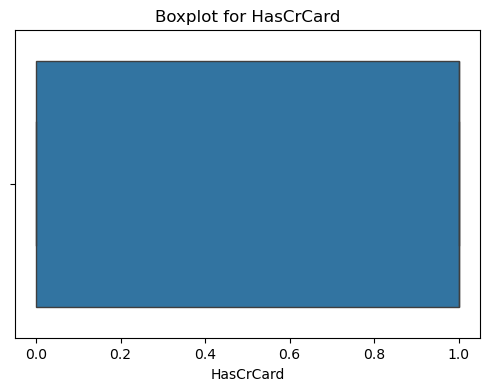

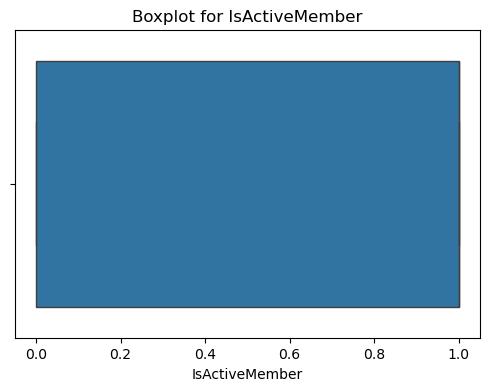

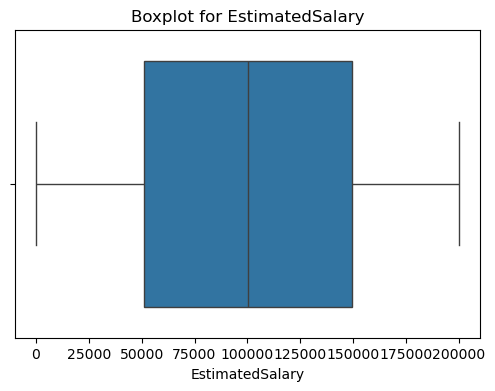

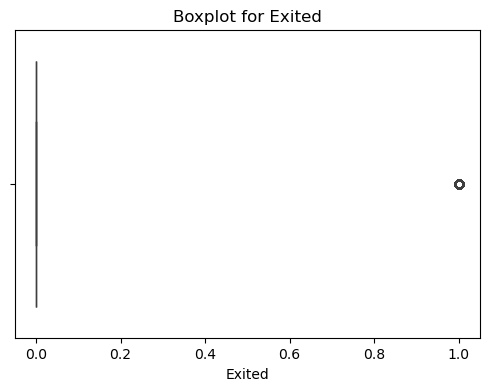

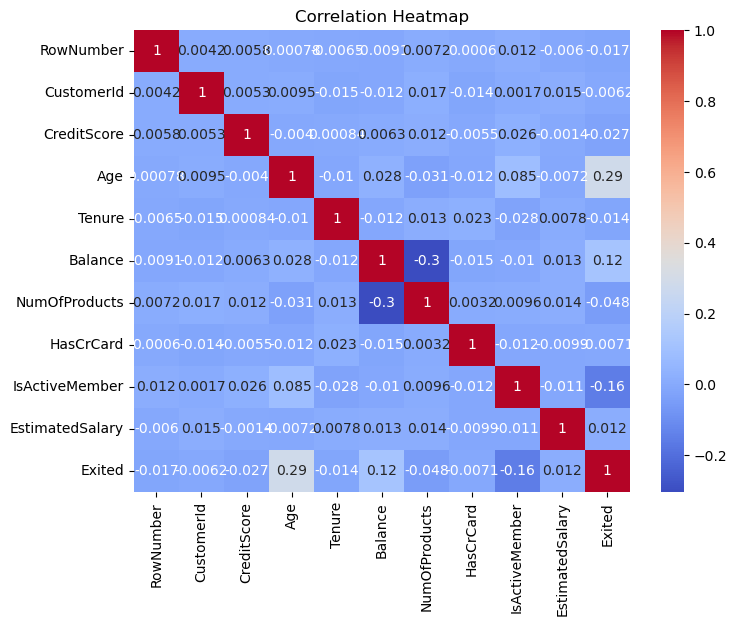

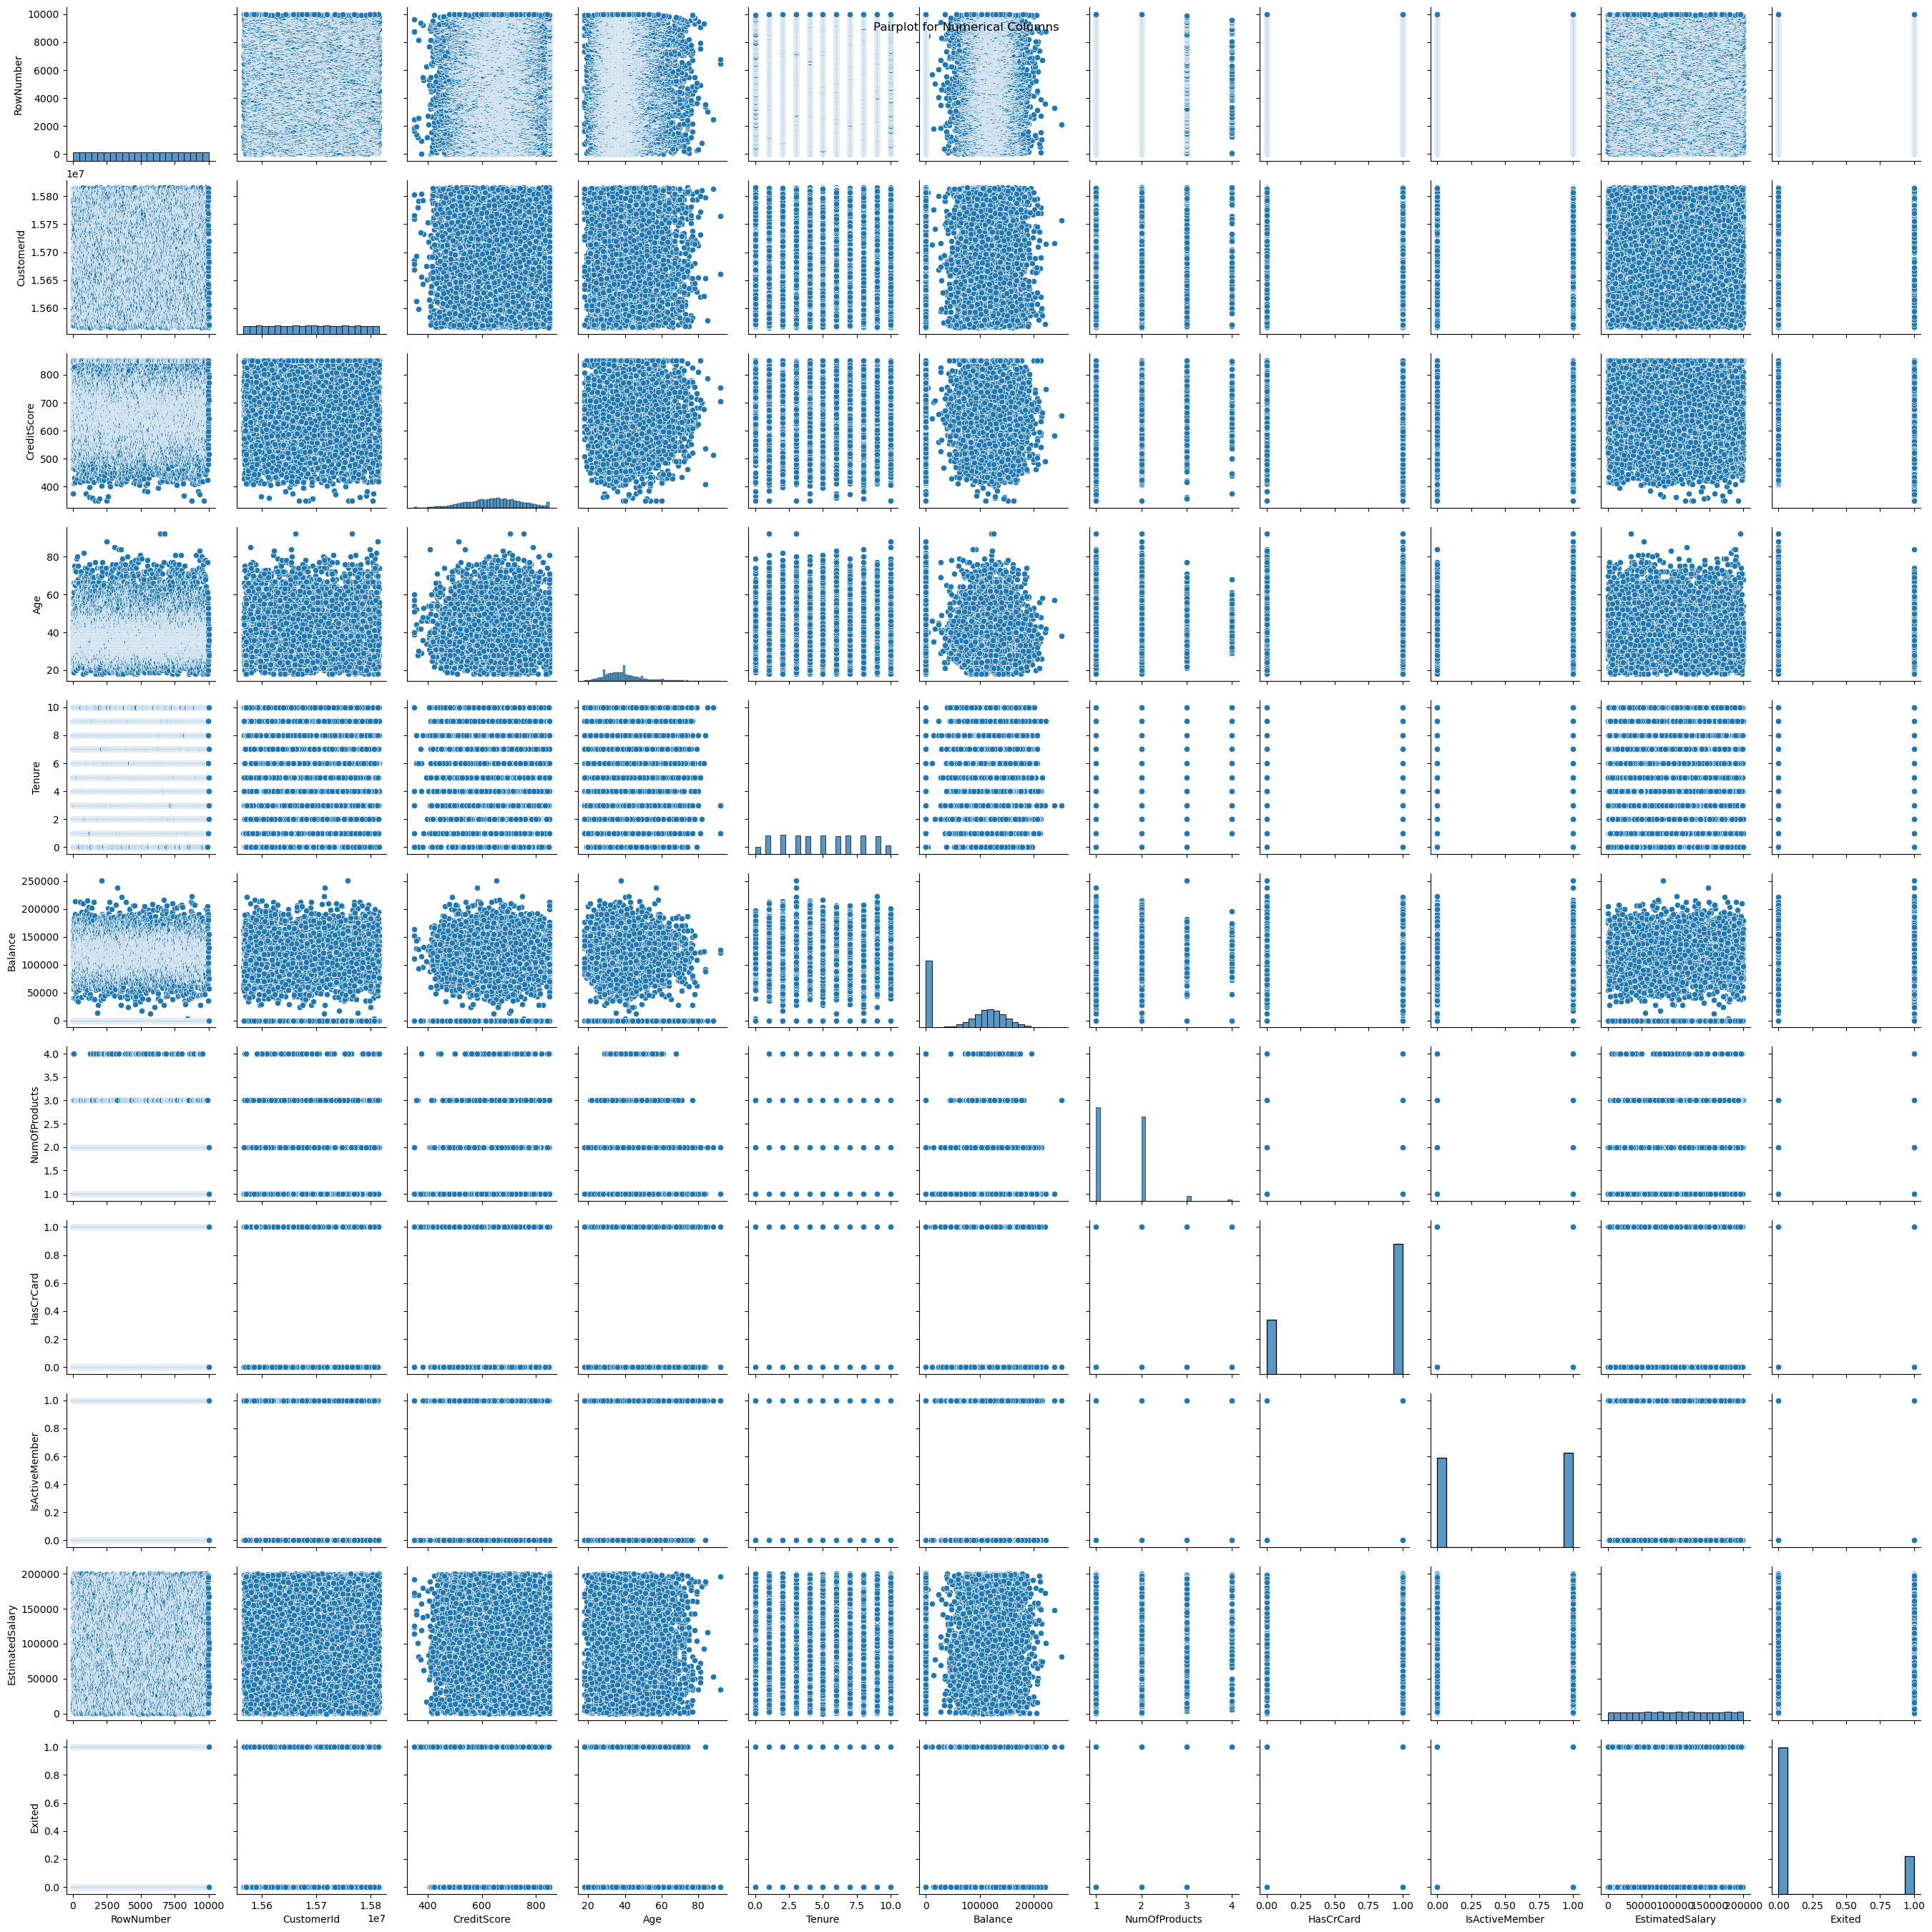

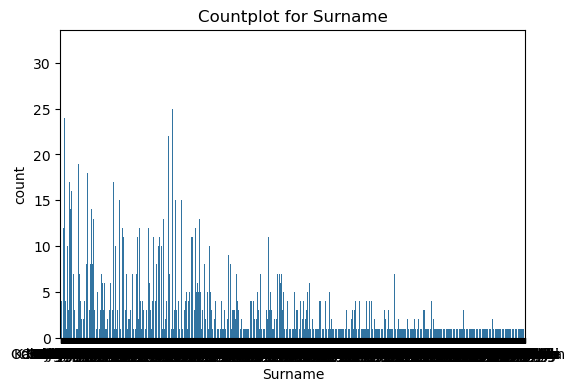

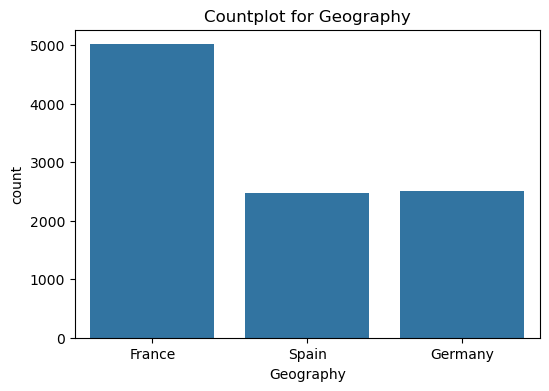

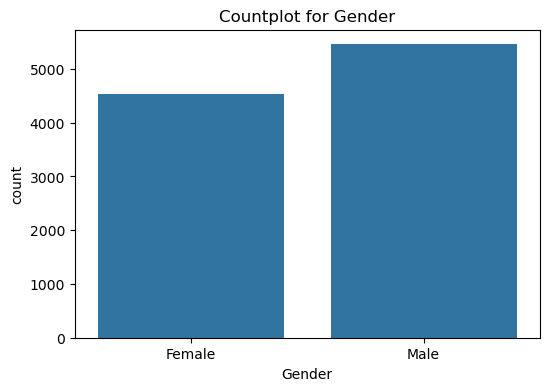

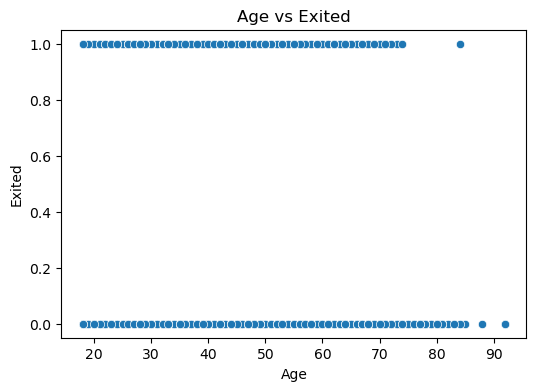

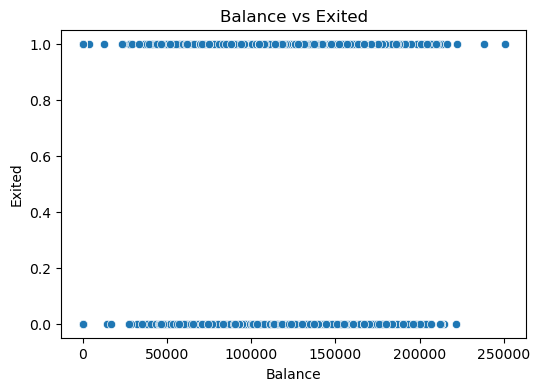

C:\Users\user\AppData\Local\Temp\ipykernel_18448\817995893.py:66: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['EstimatedSalary'])


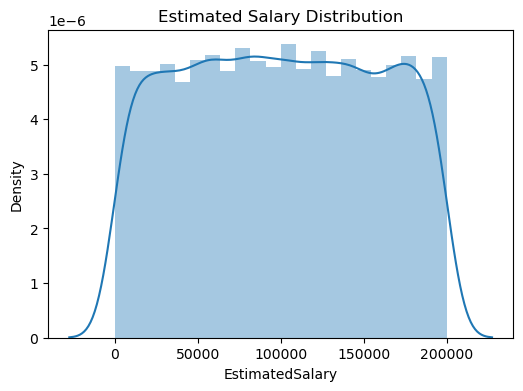

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. counterplot for target variable visualize (Exited)

plt.figure(figsize=(6, 4))
sns.countplot(x='Exited', data=df)
plt.title('Counterplot for Exited')
plt.show()

# 2. histogram for numerical columns

df_num = df.select_dtypes(include=['int64', 'float64'])
df_num.hist(figsize=(7, 5))
plt.tight_layout()
plt.suptitle('Histogram for Numerical Columns')
plt.show()

# 3. boxplot for outlierdetection

for col in df_num.columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot for {col}')
    plt.show()

# 4. correlation heatmap between numerical features

plt.figure(figsize=(8, 6))
sns.heatmap(df_num.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# 5. pairplot for check relationship and distribution among numerical features

sns.pairplot(df_num)
plt.suptitle('Pairplot for Numerical Columns')
plt.show()

# 6. countplot distribution between catagorical variable

df_cat = df.select_dtypes(include=['object'])
for col in df_cat.columns:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=df[col])
    plt.title(f'Countplot for {col}')
    plt.show()

# 7. age vs exited

plt.figure(figsize=(6, 4))
sns.scatterplot(x='Age', y='Exited', data=df)
plt.title('Age vs Exited')
plt.show()

# 8. balance vs exited

plt.figure(figsize=(6, 4))
sns.scatterplot(x='Balance', y='Exited', data=df)
plt.title('Balance vs Exited')
plt.show()

#9. estimitted salary distribution

plt.figure(figsize=(6, 4))
sns.distplot(df['EstimatedSalary'])
plt.title('Estimated Salary Distribution')
plt.show()

#

# Verdict of the 9 Charts:
# 1. Target Variable (Exited): Shows a significant class imbalance; roughly 80% stayed and 20% churned.
# 2. Histograms: Reveals Age is slightly right-skewed, while CreditScore and EstimatedSalary are relatively uniform/normal.
# 3. Boxplots: Detects outliers in 'Age' (older customers) and 'CreditScore' (very low scores).
# 4. Correlation Heatmap: Shows low linear correlation between numerical features, suggesting non-linear relationships drive churn.
# 5. Pairplot: Confirms no obvious linear clusters between numerical variables across the dataset.
# 6. Categorical Countplots: Shows 'France' is the most common geography and 'Male' is slightly more represented than 'Female'.
# 7. Age vs Exited: Suggests that older customers (40-60 range) are more likely to exit compared to younger ones.
# 8. Balance vs Exited: Reveals many customers with 0 balance, but churn occurs across all balance levels.
# 9. Salary Distribution: Confirms that salary is uniformly distributed, meaning wealth (salary-wise) isn't a direct indicator of churn.

## checking outlier using iqr method

the datapoint lying below upper and lower band kconcidr outlier

In [10]:
df_num = df.select_dtypes(include=['int64', 'float64']).drop(columns=['Exited'])

for col in df_num.columns:
    Q1 = df_num[col].quantile(0.25)
    Q3 = df_num[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    outliers = df_num[(df_num[col] < lower_bound) | (df_num[col] > upper_bound)]

    print("=" * 80)
    print(f"Column Name  : {col}")
    print(f"Lower Bound  : {lower_bound}")
    print(f"Upper Bound  : {upper_bound}")
    print(f"Outlier Count: {len(outliers)}")
    print("=" * 80)

Column Name  : RowNumber
Lower Bound  : -4998.5
Upper Bound  : 14999.5
Outlier Count: 0
Column Name  : CustomerId
Lower Bound  : 15441470.0
Upper Bound  : 15940292.0
Outlier Count: 0
Column Name  : CreditScore
Lower Bound  : 383.0
Upper Bound  : 919.0
Outlier Count: 15
Column Name  : Age
Lower Bound  : 14.0
Upper Bound  : 62.0
Outlier Count: 359
Column Name  : Tenure
Lower Bound  : -3.0
Upper Bound  : 13.0
Outlier Count: 0
Column Name  : Balance
Lower Bound  : -191466.36000000002
Upper Bound  : 319110.60000000003
Outlier Count: 0
Column Name  : NumOfProducts
Lower Bound  : -0.5
Upper Bound  : 3.5
Outlier Count: 60
Column Name  : HasCrCard
Lower Bound  : -1.5
Upper Bound  : 2.5
Outlier Count: 0
Column Name  : IsActiveMember
Lower Bound  : -1.5
Upper Bound  : 2.5
Outlier Count: 0
Column Name  : EstimatedSalary
Lower Bound  : -96577.09624999999
Upper Bound  : 296967.45375
Outlier Count: 0


## outlier capping usin iqr method

value beloww lower bound are replaced with lowe limit and value above upper bound  can replace with upper limit using clip fn.

In [11]:
df_capped = df_num.copy()
df_num = df.select_dtypes(include=['int64', 'float64']).drop(columns=['Exited'])

for col in df_num.columns:

    Q1 = df_num[col].quantile(0.25)
    Q3 = df_num[col].quantile(0.75)


    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    df_capped[col] = df_capped[col].clip(lower=lower_bound, upper=upper_bound)

    print("outlier capping completed successfully")

outlier capping completed successfully
outlier capping completed successfully
outlier capping completed successfully
outlier capping completed successfully
outlier capping completed successfully
outlier capping completed successfully
outlier capping completed successfully
outlier capping completed successfully
outlier capping completed successfully
outlier capping completed successfully


## checking  skewness
 positive skewness  for right skewed ,negative skewness left skewwed data, o normal distribution

In [12]:
df_num = df.select_dtypes(include=['int64', 'float64']).drop(columns=['Exited'])

for col in df_num.columns:
    skew_value = df_num[col].skew()

    print("=" * 80)
    print(f"Column Name  : {col}")
    print(f"Skewness     : {skew_value:.4f}")

    if skew_value > 1:
        print("The distribution is highly positively skewed.")
    elif skew_value < -1:
        print("The distribution is highly negatively skewed.")
    elif skew_value >= 0.5:
        print("The distribution is moderately positively skewed.")
    elif skew_value <= -0.5:
        print("The distribution is moderately negatively skewed.")
    else:
        print("The distribution is approximately symmetric.")

    print("=" * 80)

Column Name  : RowNumber
Skewness     : 0.0000
The distribution is approximately symmetric.
Column Name  : CustomerId
Skewness     : 0.0011
The distribution is approximately symmetric.
Column Name  : CreditScore
Skewness     : -0.0716
The distribution is approximately symmetric.
Column Name  : Age
Skewness     : 1.0113
The distribution is highly positively skewed.
Column Name  : Tenure
Skewness     : 0.0110
The distribution is approximately symmetric.
Column Name  : Balance
Skewness     : -0.1411
The distribution is approximately symmetric.
Column Name  : NumOfProducts
Skewness     : 0.7456
The distribution is moderately positively skewed.
Column Name  : HasCrCard
Skewness     : -0.9018
The distribution is moderately negatively skewed.
Column Name  : IsActiveMember
Skewness     : -0.0604
The distribution is approximately symmetric.
Column Name  : EstimatedSalary
Skewness     : 0.0021
The distribution is approximately symmetric.


# applying log transformation
use in numerical column to reduce skewness, greter than 0.5 is transformed rest excluded

In [13]:
import numpy as np

df_transformed = df_num.copy()

# select only continuous numerical columns
exclude_cols = ['Exited', 'HasCrCard', 'IsActiveMember']
df_num_selection = df_transformed.select_dtypes(include=['int64', 'float64']).drop(columns=exclude_cols, errors='ignore')

for col in df_num_selection.columns:
    skew_value = df_num_selection[col].skew()
    if abs(skew_value) > 0.5:
        if df_num_selection[col].min() <= 0:
            # Adding a constant to ensure all values are positive before log transformation if needed
            df_transformed[col] = np.log1p(df_num_selection[col] + abs(df_num_selection[col].min()) + 1)
        else:
            df_transformed[col] = np.log1p(df_num_selection[col])

        print(f"Log1p transformation completed successfully for: {col}")

Log1p transformation completed successfully for: Age
Log1p transformation completed successfully for: NumOfProducts


## rechecking skewness after log tranformation

to check low, moderate,high skewness

In [14]:
df_num_transformed = df_transformed.select_dtypes(include=['int64', 'float64']).drop(columns=['Exited'], errors='ignore')

# create skewness table
skewness_after = pd.DataFrame({
    "column": df_num_transformed.columns,
    "skewness_after_Transformation": [round(df_num_transformed[col].skew(), 3) for col in df_num_transformed.columns]
})

# categorize skewness
def skew_category(x):
    if abs(x) < 0.5:
        return "low skewed"
    elif abs(x) < 1:
        return "moderate skewed"
    else:
        return "high skewed"

skewness_after['skew_category'] = skewness_after['skewness_after_Transformation'].apply(skew_category)

# display result
display(skewness_after)

,column,skewness_after_Transformation,skew_category
0,RowNumber,0.000,low skewed
1,CustomerId,0.001,low skewed
2,CreditScore,-0.072,low skewed
3,Age,0.203,low skewed
4,Tenure,0.011,low skewed
5,Balance,-0.141,low skewed
6,NumOfProducts,0.351,low skewed
7,HasCrCard,-0.902,moderate skewed
8,IsActiveMember,-0.060,low skewed
9,EstimatedSalary,0.002,low skewed


## label coding to categorical column

convert categorical object  to numerical valu

In [15]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Create copy of the transformed dataframe
df_encoded = df_transformed.copy()

# Select categorical columns from the original dataframe
df_cat = df.select_dtypes(include=["object"])

# Initialize and apply label encoder to all selected categorical columns including Surname
le = LabelEncoder()
for col in df_cat.columns:
    df_encoded[col] = le.fit_transform(df[col])
    print(f"Label encoding completed successfully for: {col}")

print("\nAll categorical columns, including Surname, have been encoded.")
display(df_encoded.head())

Label encoding completed successfully for: Surname
Label encoding completed successfully for: Geography
Label encoding completed successfully for: Gender

All categorical columns, including Surname, have been encoded.


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Surname,Geography,Gender
0,1,15634602,619,3.761200,2,0.00,0.693147,1,1,101348.88,1115,0,0
1,2,15647311,608,3.737670,1,83807.86,0.693147,0,1,112542.58,1177,2,0
2,3,15619304,502,3.761200,8,159660.80,1.386294,1,0,113931.57,2040,0,0
3,4,15701354,699,3.688879,1,0.00,1.098612,0,0,93826.63,289,0,0
4,5,15737888,850,3.784190,2,125510.82,0.693147,1,1,79084.10,1822,2,0


## Feature selection

input feature are selected by removing unnecessary feature fro m dataset, such as row no. , custermer id , surname,and target column Exited.

In [16]:
import numpy as np
from sklearn.preprocessing import LabelEncoder

# 1. Start with the original numerical columns (excluding target for transformation)
df_num = df.select_dtypes(include=['int64', 'float64']).drop(columns=['Exited'], errors='ignore')
df_transformed = df_num.copy()

# Apply log transformation to skewed columns
for col in ['Age', 'NumOfProducts']:
    if col in df_transformed.columns:
        df_transformed[col] = np.log1p(df_transformed[col])

# 2. Add categorical columns back with encoding to create df_encoded
df_encoded = df_transformed.copy()
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df_encoded[col] = le.fit_transform(df[col])

# 3. Final Feature Selection
# We drop identifiers. 'Exited' is not in df_encoded because we started from df_num (which excluded it)
drop_cols = ['RowNumber', 'CustomerId', 'Surname', 'Exited']
x = df_encoded.drop(columns=[c for c in drop_cols if c in df_encoded.columns], axis=1)
y = df['Exited']

print("Feature matrix 'x' and target 'y' created successfully.")
print(f"Number of features: {x.shape[1]}")
print(f"Features included: {list(x.columns)}")
display(x.head())

Feature matrix 'x' and target 'y' created successfully.
Number of features: 10
Features included: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography', 'Gender']


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography,Gender
0,619,3.761200,2,0.00,0.693147,1,1,101348.88,0,0
1,608,3.737670,1,83807.86,0.693147,0,1,112542.58,2,0
2,502,3.761200,8,159660.80,1.386294,1,0,113931.57,0,0
3,699,3.688879,1,0.00,1.098612,0,0,93826.63,0,0
4,850,3.784190,2,125510.82,0.693147,1,1,79084.10,2,0


## train and test split

dataset divided into training and testing using train and test split

In [17]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42,stratify=y)

## feature scaling

standard scaler is used to converting/standardize numerical varible into common scale between 0-1

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# Converting back to DataFrame for better visibility if needed
x_train_scaled = pd.DataFrame(x_train_scaled, columns=x.columns)
x_test_scaled = pd.DataFrame(x_test_scaled, columns=x.columns)

print("Feature scaling completed successfully.")
display(x_train_scaled.head())

Feature scaling completed successfully.


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography,Gender
0,1.058568,1.609632,0.684723,-1.226059,-0.946334,0.641042,-1.030206,1.042084,-0.905933,0.907507
1,0.913626,-0.630563,-0.696202,0.413288,-0.946334,0.641042,-1.030206,-0.623556,0.300168,0.907507
2,1.079274,-0.070138,-1.731895,0.601687,0.882834,0.641042,0.970680,0.308128,0.300168,-1.101919
3,-0.929207,-0.070138,-0.005739,-1.226059,0.882834,0.641042,-1.030206,-0.290199,-0.905933,0.907507
4,0.427035,1.020044,0.339492,0.548318,0.882834,-1.559960,0.970680,0.135042,0.300168,0.907507


## Building the Artificial Neural Network (ANN)

We will now construct the ANN model. Following the assignment requirements, we will:
1. Initialize a Sequential model.
2. Add an input layer and multiple hidden layers with ReLU activation.
3. Implement **Dropout** regularization to prevent overfitting.
4. Add an output layer with a Sigmoid activation function (since this is a binary classification task).
5. Use **Early Stopping** and **Model Checkpoint** during the training process.

In [21]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import os

# 1. Ensure Dataset is Loaded
if not os.path.exists('Churn _Modeling.csv'):
    !wget https://raw.githubusercontent.com/sharmaroshan/Churn-Modelling-Dataset/master/Churn_Modelling.csv -O Churn_Modelling.csv

df = pd.read_csv('Churn _Modeling.csv')

# 2. Re-run Preprocessing
df_num = df.select_dtypes(include=['int64', 'float64']).drop(columns=['Exited'], errors='ignore')
df_transformed = df_num.copy()
for col in ['Age', 'NumOfProducts']:
    if col in df_transformed.columns:
        df_transformed[col] = np.log1p(df_transformed[col])

df_encoded = df_transformed.copy()
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df_encoded[col] = le.fit_transform(df[col])

# 3. Final Feature Selection and Data Split
drop_cols = ['RowNumber', 'CustomerId', 'Surname', 'Exited']
x_final = df_encoded.drop(columns=[c for c in drop_cols if c in df_encoded.columns], axis=1)
y_final = df['Exited']

x_train, x_test, y_train, y_test = train_test_split(x_final, y_final, test_size=0.2, random_state=42, stratify=y_final)

# 4. Apply scaling
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# 5. Define Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
model_checkpoint = ModelCheckpoint('best_model.keras', monitor='val_loss', save_best_only=True)

# 6. Initialize the ANN
ann = Sequential()

# Adding the input layer and the first hidden layer
ann.add(Dense(64, activation='relu', input_dim=x_train_scaled.shape[1]))
ann.add(Dropout(0.3))

# Adding the second hidden layer
ann.add(Dense(32, activation='relu'))
ann.add(Dropout(0.2))

# Adding the third layer
ann.add(Dense(16, activation='relu'))

# Output layer
ann.add(Dense(1, activation='sigmoid'))

# Compiling
ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 7. Training
history = ann.fit(
    x_train_scaled, y_train,
    batch_size=32,
    epochs=100,
    validation_split=0.2,
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)

print("\nANN Model training completed.")

C:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7658 - loss: 0.5115 - val_accuracy: 0.8075 - val_loss: 0.4394
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8092 - loss: 0.4412 - val_accuracy: 0.8338 - val_loss: 0.4245
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8120 - loss: 0.4314 - val_accuracy: 0.8462 - val_loss: 0.4083
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8234 - loss: 0.4227 - val_accuracy: 0.8475 - val_loss: 0.3924
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.8298 - loss: 0.4044 - val_accuracy: 0.8512 - val_loss: 0.3772
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8355 - loss: 0.3937 - val_accuracy: 0.8537 - val_loss: 0.3668
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8384 - loss: 0.3831 - val_accuracy: 0.8631 - val_loss: 0.3537
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8423 - loss: 0.3781 - val_

## Ann model evaluation

evaluated by training an testing predicction, loss curveanalyse by each epochs,
overftting and underfitting , or good fit is checked by differece betwwen training and testing accuracy

## result Dataframe

250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step   
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


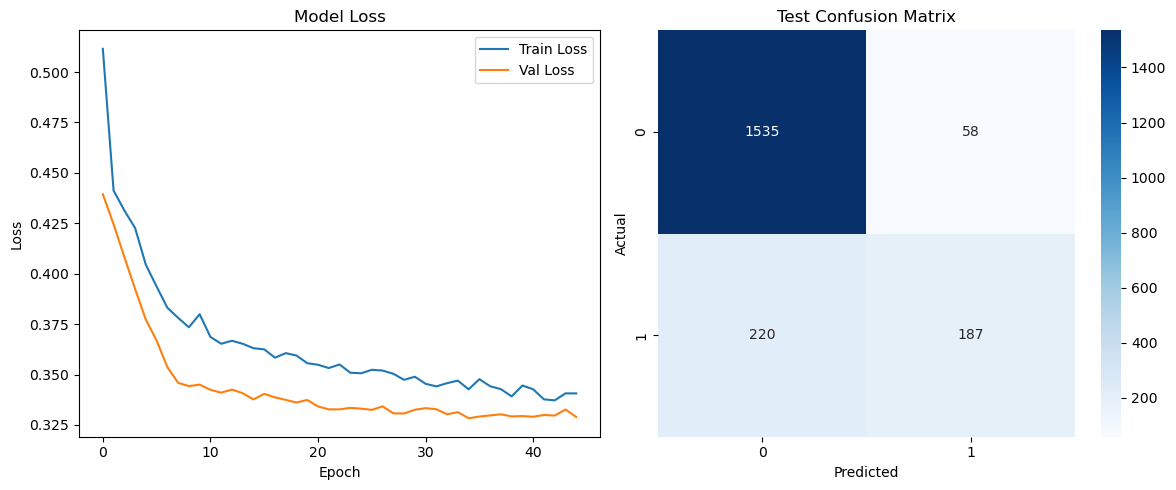

,Model,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1 Score,Test F1 Score,Train Roc Auc Score,Test Roc Auc Score,Difference,Status
0,ANN,0.8691,0.861,0.7889,0.7633,0.4883,0.4595,0.6033,0.5736,0.8762,0.8492,0.0081,good fit


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, roc_auc_score, f1_score

# 1. Generate Predictions
# Probability outputs
train_probs = ann.predict(x_train_scaled)
test_probs = ann.predict(x_test_scaled)

# Binary class outputs
train_pred = (train_probs > 0.5).astype(int)
test_pred = (test_probs > 0.5).astype(int)

# 2. Calculate Metrics
# Accuracy
train_accuracy = accuracy_score(y_train, train_pred)
test_accuracy = accuracy_score(y_test, test_pred)

# Precision
train_precision = precision_score(y_train, train_pred)
test_precision = precision_score(y_test, test_pred)

# Recall
train_recall = recall_score(y_train, train_pred)
test_recall = recall_score(y_test, test_pred)

# F1 score
train_f1 = f1_score(y_train, train_pred)
test_f1 = f1_score(y_test, test_pred)

# Roc auc score
train_roc_auc = roc_auc_score(y_train, train_probs)
test_roc_auc = roc_auc_score(y_test, test_probs)

# 3. Overfitting Analysis
difference = train_accuracy - test_accuracy

if difference > 0.10:
    status = "overfitting"
elif difference < -0.05:
    status = "underfitting"
else:
    status = "good fit"

# 4. Visualization
plt.figure(figsize=(12, 5))

# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Confusion Matrix for Test Set
plt.subplot(1, 2, 2)
cm = confusion_matrix(y_test, test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Test Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()

# 5. Result Dataframe
df_result_ann = pd.DataFrame({
    'Model': ['ANN'],
    'Train Accuracy': [round(train_accuracy, 4)],
    'Test Accuracy': [round(test_accuracy, 4)],
    'Train Precision': [round(train_precision, 4)],
    'Test Precision': [round(test_precision, 4)],
    'Train Recall': [round(train_recall, 4)],
    'Test Recall': [round(test_recall, 4)],
    'Train F1 Score': [round(train_f1, 4)],
    'Test F1 Score': [round(test_f1, 4)],
    'Train Roc Auc Score': [round(train_roc_auc, 4)],
    'Test Roc Auc Score': [round(test_roc_auc, 4)],
    'Difference': [round(difference, 4)],
    'Status': [status]
})

display(df_result_ann)

## Applying  SMOTE  FOr resolve class imbalance issue in target  varible

it increses more synthetic sample at minority class

In [23]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
x_train_sm, y_train_sm = smote.fit_resample(x_train_scaled, y_train)

print(y_train.value_counts())
print(y_train_sm.value_counts())

Exited
0    6370
1    1630
Name: count, dtype: int64
Exited
1    6370
0    6370
Name: count, dtype: int64


In [24]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Initialize the ANN for balanced data
ann_smote = Sequential([
    Dense(64, activation='relu', input_dim=x_train_sm.shape[1]),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

ann_smote.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_model_smote.keras', monitor='val_loss', save_best_only=True)

# Training the model on resampled data with validation_split enabled
history_smote = ann_smote.fit(
    x_train_sm, y_train_sm,
    batch_size=32,
    epochs=100,
    validation_split=0.2,

)

print("\nANN Training on SMOTE-balanced data completed.")

C:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
319/319 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6934 - loss: 0.5790 - val_accuracy: 0.5455 - val_loss: 0.7323
Epoch 2/100
319/319 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7325 - loss: 0.5328 - val_accuracy: 0.5934 - val_loss: 0.6908
Epoch 3/100
319/319 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7556 - loss: 0.5015 - val_accuracy: 0.6024 - val_loss: 0.6707
Epoch 4/100
319/319 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7670 - loss: 0.4808 - val_accuracy: 0.6535 - val_loss: 0.6086
Epoch 5/100
319/319 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7722 - loss: 0.4692 - val_accuracy: 0.6586 - val_loss: 0.6325
Epoch 6/100
319/319 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7853 - loss: 0.4563 - val_accuracy: 0.6754 - val_loss: 0.5772
Epoch 7/100
319/319 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7815 - loss: 0.4551 - val_accuracy: 0.5832 - val_loss: 0.6718
Epoch 8/100
319/319 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7871 - loss: 0.4478 - val_accu

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step  


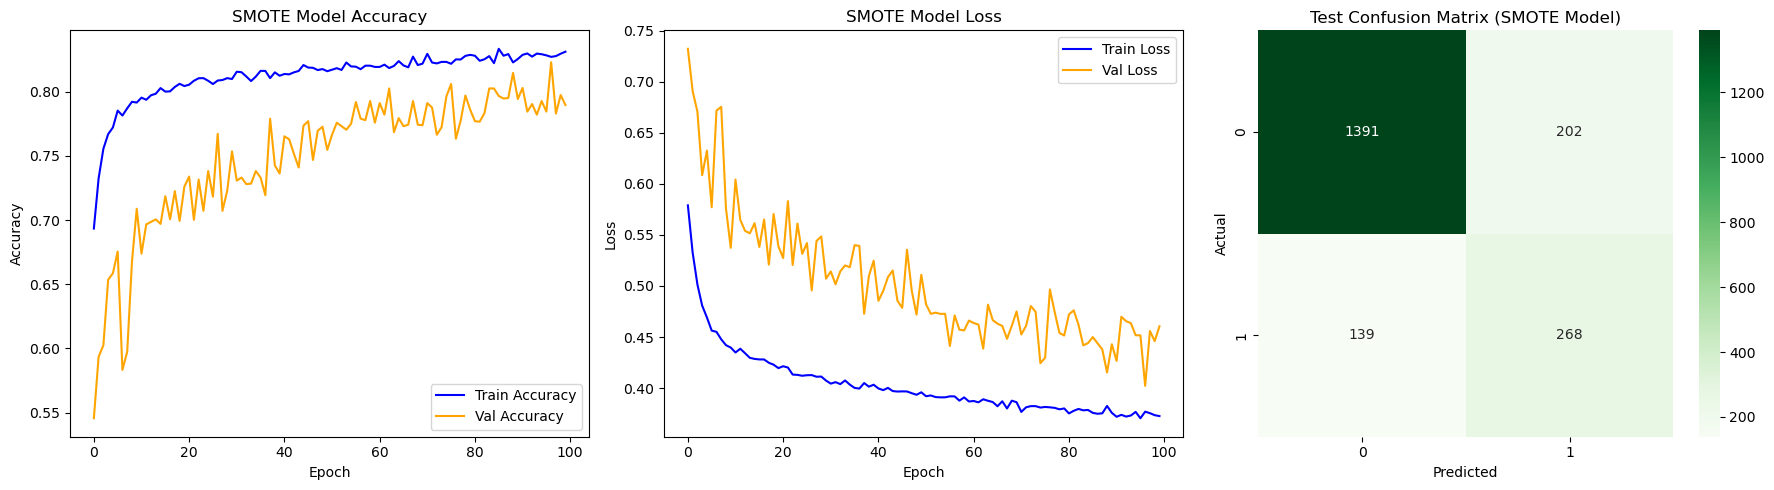

,Model,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1 Score,Test F1 Score,Train Roc Auc Score,Test Roc Auc Score,Difference,Status
0,ANN (SMOTE),0.8691,0.8295,0.7889,0.5702,0.4883,0.6585,0.6033,0.6112,0.8762,0.8394,0.0396,good fit


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, roc_auc_score, f1_score

# 1. Generate Predictions for the SMOTE model
test_probs_smote = ann_smote.predict(x_test_scaled)
test_pred_smote = (test_probs_smote > 0.5).astype(int)

# 2. Calculate Metrics
accuracy_smote = accuracy_score(y_test, test_pred_smote)
precision_smote = precision_score(y_test, test_pred_smote)
recall_smote = recall_score(y_test, test_pred_smote)
f1_smote = f1_score(y_test, test_pred_smote)
roc_auc_smote = roc_auc_score(y_test, test_probs_smote)

# 3. Visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Accuracy Curve
axes[0].plot(history_smote.history['accuracy'], label='Train Accuracy', color='blue')
axes[0].plot(history_smote.history['val_accuracy'], label='Val Accuracy', color='orange')
axes[0].set_title('SMOTE Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss Curve
axes[1].plot(history_smote.history['loss'], label='Train Loss', color='blue')
axes[1].plot(history_smote.history['val_loss'], label='Val Loss', color='orange')
axes[1].set_title('SMOTE Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

# Confusion Matrix
cm_smote = confusion_matrix(y_test, test_pred_smote)
sns.heatmap(cm_smote, annot=True, fmt='d', cmap='Greens', ax=axes[2])
axes[2].set_title('Test Confusion Matrix (SMOTE Model)')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# difference
difference_smote = train_accuracy - accuracy_smote

# overfitting check

if difference_smote > 0.10:
    status_smote = "overfitting"
elif difference_smote < -0.05:
    status_smote = "underfitting"
else:
    status_smote = "good fit"

#  result dataframe
df_result_ann_smote = pd.DataFrame({
    'Model': ['ANN (SMOTE)'],
    'Train Accuracy': [round(train_accuracy, 4)],
    'Test Accuracy': [round(accuracy_smote, 4)],

    'Train Precision': [round(train_precision, 4)],
    'Test Precision': [round(precision_smote, 4)],

    'Train Recall': [round(train_recall, 4)],
    'Test Recall': [round(recall_smote, 4)],

    'Train F1 Score': [round(train_f1, 4)],
    'Test F1 Score': [round(f1_smote, 4)],

    'Train Roc Auc Score': [round(train_roc_auc, 4)],
    'Test Roc Auc Score': [round(roc_auc_smote, 4)],

    'Difference': [round(difference_smote, 4)],

    'Status': [status_smote]
})

display(df_result_ann_smote)





## saving the smote ANN model

trained smote  ann model can sved in keras formate for future deployment and prediction

In [26]:
# save final model
ann_smote.save("smote_ann_model.keras")

print("model saved successfully")

model saved successfully


## deep Ann model with early and model checkpoint

dropout layer added to reduce overfitting ang generalizing

model is trainesd on smote balanced dataset

In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Initialize the ANN for balanced data
model = Sequential()

model.add(Dense(64, activation='relu', input_dim=x_train_sm.shape[1]))
model.add(Dropout(0.3))

model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(16, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(1, activation='sigmoid'))

# compile
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Define callbacks early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

#modelcheckpoint
checkpoint = ModelCheckpoint('best_model_deep.keras', monitor='val_loss', save_best_only=True,mode="min",verbose=1)


#train model
history_deep = model.fit(
    x_train_sm, y_train_sm,
    batch_size=32,
    epochs=100,
    validation_split=0.2,
    validation_data=(x_test_scaled, y_test),
    callbacks=[early_stopping, checkpoint]
)


C:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
394/399 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5943 - loss: 0.6607
Epoch 1: val_loss improved from None to 0.54806, saving model to best_model_deep.keras

Epoch 1: finished saving model to best_model_deep.keras
399/399 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.6557 - loss: 0.6193 - val_accuracy: 0.7280 - val_loss: 0.5481
Epoch 2/100
393/399 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7225 - loss: 0.5511
Epoch 2: val_loss improved from 0.54806 to 0.51446, saving model to best_model_deep.keras

Epoch 2: finished saving model to best_model_deep.keras
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7288 - loss: 0.5456 - val_accuracy: 0.7315 - val_loss: 0.5145
Epoch 3/100
394/399 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7471 - loss: 0.5163
Epoch 3: val_loss improved from 0.51446 to 0.46558, saving model to best_model_deep.keras

Epoch 3: finished saving model to best_model_deep.keras
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7488 - loss

##  Ann smote early stoping model evaluation by graph

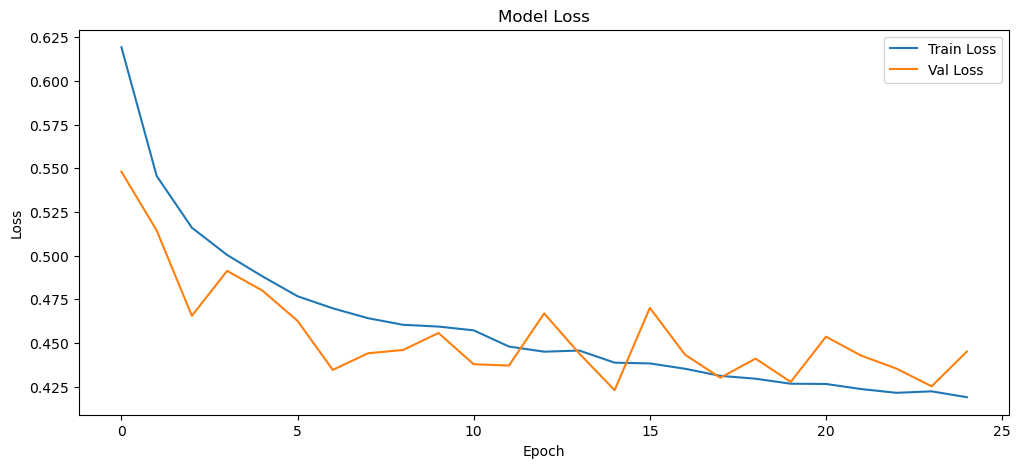

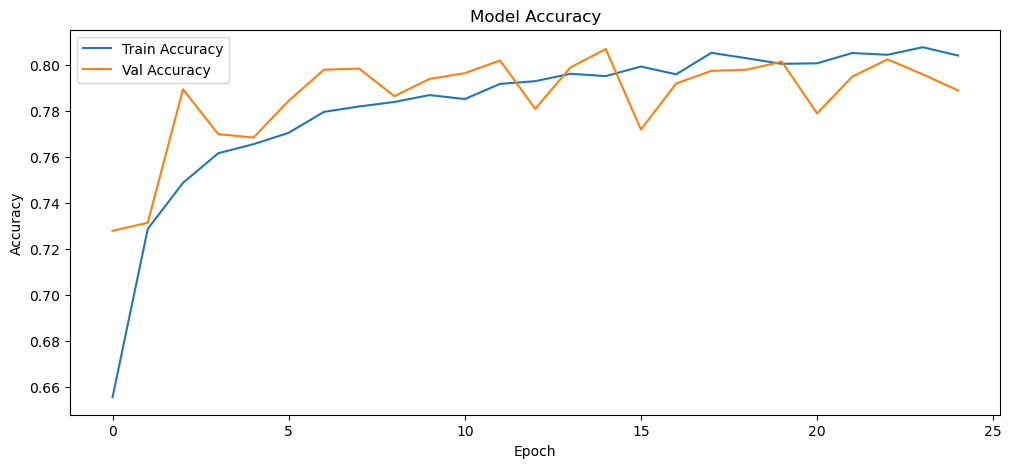

250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step  
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


,Model,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1 Score,Test F1 Score,Train Roc Auc Score,Test Roc Auc Score,Difference,Status
0,ANN (Deep),0.8154,0.807,0.5343,0.5187,0.7307,0.7174,0.6173,0.6021,0.8785,0.8561,0.0084,good fit


In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, roc_auc_score, f1_score

# loss curve
plt.figure(figsize=(12, 5))
plt.plot(history_deep.history['loss'], label='Train Loss')
plt.plot(history_deep.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# accuracy curve
plt.figure(figsize=(12, 5))
plt.plot(history_deep.history['accuracy'], label='Train Accuracy')
plt.plot(history_deep.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# prediction probability
train_probs_deep = model.predict(x_train_scaled)
test_probs_deep = model.predict(x_test_scaled)

# convert probability into classes
train_pred_deep = (train_probs_deep > 0.5).astype(int)
test_pred_deep = (test_probs_deep > 0.5).astype(int)

# metrics
train_accuracy_deep = accuracy_score(y_train, train_pred_deep)
test_accuracy_deep = accuracy_score(y_test, test_pred_deep)

train_precision_deep = precision_score(y_train, train_pred_deep)
test_precision_deep = precision_score(y_test, test_pred_deep)

train_recall_deep = recall_score(y_train, train_pred_deep)
test_recall_deep = recall_score(y_test, test_pred_deep)

train_f1_deep = f1_score(y_train, train_pred_deep)
test_f1_deep = f1_score(y_test, test_pred_deep)

train_roc_auc_deep = roc_auc_score(y_train, train_probs_deep)
test_roc_auc_deep = roc_auc_score(y_test, test_probs_deep)

difference_deep = train_accuracy_deep - test_accuracy_deep

if difference_deep > 0.10:
    status_deep = "overfitting"
elif difference_deep < -0.05:
    status_deep = "underfitting"
else:
    status_deep = "good fit"

# result Dataframe
df_result_ann_deep = pd.DataFrame({
    'Model': ['ANN (Deep)'],
    'Train Accuracy': [round(train_accuracy_deep, 4)],
    'Test Accuracy': [round(test_accuracy_deep, 4)],
    'Train Precision': [round(train_precision_deep, 4)],
    'Test Precision': [round(test_precision_deep, 4)],
    'Train Recall': [round(train_recall_deep, 4)],
    'Test Recall': [round(test_recall_deep, 4)],
    'Train F1 Score': [round(train_f1_deep, 4)],
    'Test F1 Score': [round(test_f1_deep, 4)],
    'Train Roc Auc Score': [round(train_roc_auc_deep, 4)],
    'Test Roc Auc Score': [round(test_roc_auc_deep, 4)],
    'Difference': [round(difference_deep, 4)],
    'Status': [status_deep]
})

display(df_result_ann_deep)

## saving final model

In [29]:
# save final model

model.save("deep_ann_model.keras")

print("model saved successfully")

model saved successfully


## hyper tuning the model using keras tuner

In [31]:
!pip install -q -U keras-tuner
import keras_tuner as kt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# function for keras tuner
def build_model(hp):
    model = Sequential()
    model.add(Dense(units=hp.Int('units', min_value=32, max_value=256, step=32),
                    activation='relu', input_dim=x_train_sm.shape[1]))

    model.add(Dropout(hp.Float('dropout_1', min_value=0.1, max_value=0.5, step=0.1)))

    # Add variable number of hidden layers
    for i in range(hp.Int('num_layers', 1, 3)):
        model.add(Dense(units=hp.Int(f'units_{i}', min_value=32, max_value=128, step=32), activation='relu'))
        model.add(Dropout(hp.Float(f'dropout_{i+2}', min_value=0.1, max_value=0.5, step=0.1)))

    # Output layer
    model.add(Dense(1, activation='sigmoid'))

    # Fix: use hp.Choice instead of hp.choice
    model.compile(optimizer=hp.Choice("optimizer", values=["adam", "rmsprop"]),
                  loss='binary_crossentropy', metrics=['accuracy'])

    return model

# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_model_tuner.keras', monitor='val_loss', save_best_only=True, mode="min", verbose=0)

# Initialize Tuner
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=5,
    executions_per_trial=1,
    directory='keras_tuner_ann',
    project_name='ann_smote_tuner',
    overwrite=True
)

# Run Search
tuner.search(x_train_sm, y_train_sm, epochs=50, validation_split=0.2, callbacks=[early_stopping, checkpoint])

# Retrieve results
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print("\nBest Hyperparameters:")
print(f"Initial Units: {best_hps.get('units')}")
print(f"Number of Layers: {best_hps.get('num_layers')}")
print(f"Optimizer: {best_hps.get('optimizer')}")

# Get and evaluate best model
best_model = tuner.get_best_models(num_models=1)[0]
loss, accuracy = best_model.evaluate(x_test_scaled, y_test)

print(f"\nTest Loss: {round(loss, 4)}")
print(f"Test Accuracy: {round(accuracy, 4)}")

# Save the best model found by tuner
best_model.save("best_model_tuner_final.keras")

Trial 2 Complete [00h 00m 00s]

Best val_accuracy So Far: None
Total elapsed time: 00h 00m 00s

Search: Running Trial #3

Value             |Best Value So Far |Hyperparameter
128               |192               |units
0.3               |0.1               |dropout_1
3                 |3                 |num_layers
96                |96                |units_0
0.2               |0.2               |dropout_2
rmsprop           |rmsprop           |optimizer



Traceback (most recent call last):
  File "C:\Users\user\anaconda3\Lib\site-packages\keras_tuner\src\engine\base_tuner.py", line 274, in _try_run_and_update_trial
    self._run_and_update_trial(trial, *fit_args, **fit_kwargs)
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\user\anaconda3\Lib\site-packages\keras_tuner\src\engine\base_tuner.py", line 239, in _run_and_update_trial
    results = self.run_trial(trial, *fit_args, **fit_kwargs)
  File "C:\Users\user\anaconda3\Lib\site-packages\keras_tuner\src\engine\tuner.py", line 309, in run_trial
    self._configure_tensorboard_dir(callbacks, trial, execution)
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\user\anaconda3\Lib\site-packages\keras_tuner\src\engine\tuner.py", line 421, in _configure_tensorboard_dir
    from tensorboard.plugins.hparams import api as hparams_api
ModuleNotFoundError: No module named 'tensorboard'


RuntimeError: Number of consecutive failures exceeded the limit of 3.
Traceback (most recent call last):
  File "C:\Users\user\anaconda3\Lib\site-packages\keras_tuner\src\engine\base_tuner.py", line 274, in _try_run_and_update_trial
    self._run_and_update_trial(trial, *fit_args, **fit_kwargs)
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\user\anaconda3\Lib\site-packages\keras_tuner\src\engine\base_tuner.py", line 239, in _run_and_update_trial
    results = self.run_trial(trial, *fit_args, **fit_kwargs)
  File "C:\Users\user\anaconda3\Lib\site-packages\keras_tuner\src\engine\tuner.py", line 309, in run_trial
    self._configure_tensorboard_dir(callbacks, trial, execution)
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\user\anaconda3\Lib\site-packages\keras_tuner\src\engine\tuner.py", line 421, in _configure_tensorboard_dir
    from tensorboard.plugins.hparams import api as hparams_api
ModuleNotFoundError: No module n

## Final Model Comparison and Selection

We will now compare the performance of our three primary models trained on the SMOTE-balanced dataset:
1. **Base SMOTE ANN**: The initial model with standard architecture.
2. **Manual Deep ANN**: The version with more layers and specific dropout settings that previously showed strong recall.
3. **Tuner-Optimized ANN**: The model found via `RandomSearch`.

The goal is to find the best balance between Accuracy and Recall for churn prediction.

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Prepare metrics for the Tuner model (already evaluated in previous cell)
tuner_probs = best_model.predict(x_test_scaled)
tuner_pred = (tuner_probs > 0.5).astype(int)

# Create a consolidated comparison table
comparison_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC'],
    'Base SMOTE ANN': [
        df_result_ann_smote['Test Accuracy'].values[0],
        df_result_ann_smote['Test Precision'].values[0],
        df_result_ann_smote['Test Recall'].values[0],
        df_result_ann_smote['Test F1 Score'].values[0],
        df_result_ann_smote['Test Roc Auc Score'].values[0]
    ],
    'Manual Deep ANN': [
        df_result_ann_deep['Test Accuracy'].values[0],
        df_result_ann_deep['Test Precision'].values[0],
        df_result_ann_deep['Test Recall'].values[0],
        df_result_ann_deep['Test F1 Score'].values[0],
        df_result_ann_deep['Test Roc Auc Score'].values[0]
    ],
    'Tuner-Optimized ANN': [
        round(accuracy_score(y_test, tuner_pred), 4),
        round(precision_score(y_test, tuner_pred), 4),
        round(recall_score(y_test, tuner_pred), 4),
        round(f1_score(y_test, tuner_pred), 4),
        round(roc_auc_score(y_test, tuner_probs), 4)
    ]
}

final_comparison_df = pd.DataFrame(comparison_data)
display(final_comparison_df)

# Identify best model based on F1-Score (often best for imbalanced/balanced churn tasks)
best_idx = final_comparison_df.iloc[3, 1:].astype(float).idxmax()
print(f"\nRecommended Model for Deployment: {best_idx} (Highest F1-Score)")

## saving the best tunned ann model

in keras  format

In [32]:
# save model
ann_smote.save('base_smote_ann_model.keras')
print("Base SMOTE ANN model saved successfully in Keras format.")

Base SMOTE ANN model saved successfully in Keras format.


## saving scaler object
the trained standard  scale objectr is saved using for future data preprocessing during model, deployment

In [33]:
# save scaler

import pickle

with open("scaler.pkl","wb") as file:
    pickle.dump(scaler, file)

print("scaler  saved successfully")

scaler  saved successfully


## streamlit Application for customer churn prediction

In [34]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import pickle
from tensorflow.keras.models import load_model

# Set page config
st.set_page_config(page_title="Customer Churn Predictor", layout="centered")

# Load the saved model and scaler
@st.cache_resource
def load_resources():
    model = load_model('base_smote_ann_model.keras')
    with open('scaler.pkl', 'rb') as f:
        scaler = pickle.load(f)
    return model, scaler

model, scaler = load_resources()

st.title("🏦 Bank Customer Churn Prediction")
st.write("Enter customer details below to predict the likelihood of churning.")

# Layout for inputs
col1, col2 = st.columns(2)

with col1:
    credit_score = st.number_input("Credit Score", min_value=300, max_value=850, value=600)
    geography = st.selectbox("Geography", ["France", "Germany", "Spain"])
    gender = st.selectbox("Gender", ["Female", "Male"])
    age = st.number_input("Age", min_value=18, max_value=100, value=40)
    tenure = st.slider("Tenure (Years)", 0, 10, 5)

with col2:
    balance = st.number_input("Balance", min_value=0.0, value=0.0, format="%.2f")
    num_products = st.selectbox("Number of Products", [1, 2, 3, 4])
    has_cr_card = st.selectbox("Has Credit Card?", ["Yes", "No"])
    is_active = st.selectbox("Is Active Member?", ["Yes", "No"])
    salary = st.number_input("Estimated Salary", min_value=0.0, value=50000.0, format="%.2f")

# Preprocess user input
if st.button("Predict Churn"):
    # Encode categorical inputs (Matching training LabelEncoder logic)
    geo_map = {"France": 0, "Germany": 1, "Spain": 2}
    gen_map = {"Female": 0, "Male": 1}
    bin_map = {"Yes": 1, "No": 0}

    # Prepare the raw feature array
    # Order must match training: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography', 'Gender']
    input_data = pd.DataFrame({
        'CreditScore': [credit_score],
        'Age': [np.log1p(age)], # Log transform as applied in training
        'Tenure': [tenure],
        'Balance': [balance],
        'NumOfProducts': [np.log1p(num_products)], # Log transform as applied in training
        'HasCrCard': [bin_map[has_cr_card]],
        'IsActiveMember': [bin_map[is_active]],
        'EstimatedSalary': [salary],
        'Geography': [geo_map[geography]],
        'Gender': [gen_map[gender]]
    })

    # Scale features
    input_scaled = scaler.transform(input_data)

    # Make prediction
    prediction_prob = model.predict(input_scaled)[0][0]
    prediction = (prediction_prob > 0.5).astype(int)

    # Results display
    st.divider()
    if prediction == 1:
        st.error(f"🚨 Alert: High probability of Churn ({prediction_prob:.2%})")
        st.write("Consider offering retention incentives to this customer.")
    else:
        st.success(f"✅ Low Risk: Customer is likely to Stay ({1 - prediction_prob:.2%})")

Overwriting app.py


In [ ]:
! streamlit run app.py